In [1]:
# BITCOIN PRICE PREDICTION PROJECT

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import (
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error
)

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [2]:
# LOAD DATA

try:
    df = pd.read_excel("BTC-USD.xlsx", parse_dates=["Date"])
except:
    df = pd.read_csv("BTC-USD.csv", parse_dates=["Date"])

df = df.sort_values("Date")
df = df.set_index("Date")

# Close column check
if "Close" not in df.columns:
    raise Exception("Dataset must contain a 'Close' column.")

print("Data Loaded Successfully!")
print(df.head())

Data Loaded Successfully!
                  Open        High         Low       Close   Adj Close  \
Date                                                                     
2014-10-10  364.687012  375.066986  352.963013  361.562012  361.562012   
2014-10-11  361.362000  367.191010  355.950989  362.299011  362.299011   
2014-10-12  362.605988  379.433014  356.144012  378.549011  378.549011   
2014-10-13  377.920990  397.226013  368.897003  390.414001  390.414001   
2014-10-14  391.691986  411.697998  391.324005  400.869995  400.869995   

              Volume  
Date                  
2014-10-10  43665700  
2014-10-11  13345200  
2014-10-12  17552800  
2014-10-13  35221400  
2014-10-14  38491500  


In [3]:
# BASIC CLEANING & FULL DATE INDEX FIX

full_dates = pd.date_range(df.index.min(), df.index.max(), freq="D")
df = df.reindex(full_dates)
df = df.ffill().bfill()  # fill missing values

print("\nAfter Cleaning:")
print(df.head())


After Cleaning:
                  Open        High         Low       Close   Adj Close  \
2014-10-10  364.687012  375.066986  352.963013  361.562012  361.562012   
2014-10-11  361.362000  367.191010  355.950989  362.299011  362.299011   
2014-10-12  362.605988  379.433014  356.144012  378.549011  378.549011   
2014-10-13  377.920990  397.226013  368.897003  390.414001  390.414001   
2014-10-14  391.691986  411.697998  391.324005  400.869995  400.869995   

              Volume  
2014-10-10  43665700  
2014-10-11  13345200  
2014-10-12  17552800  
2014-10-13  35221400  
2014-10-14  38491500  


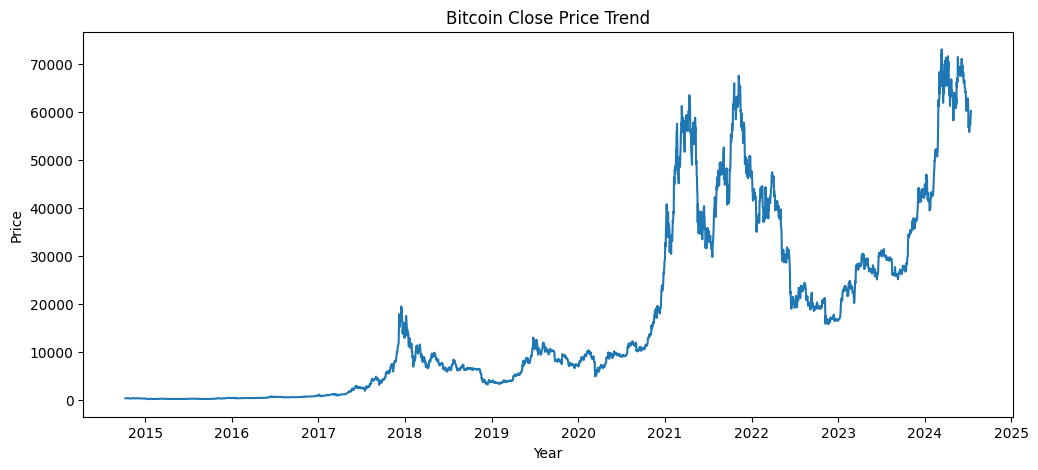

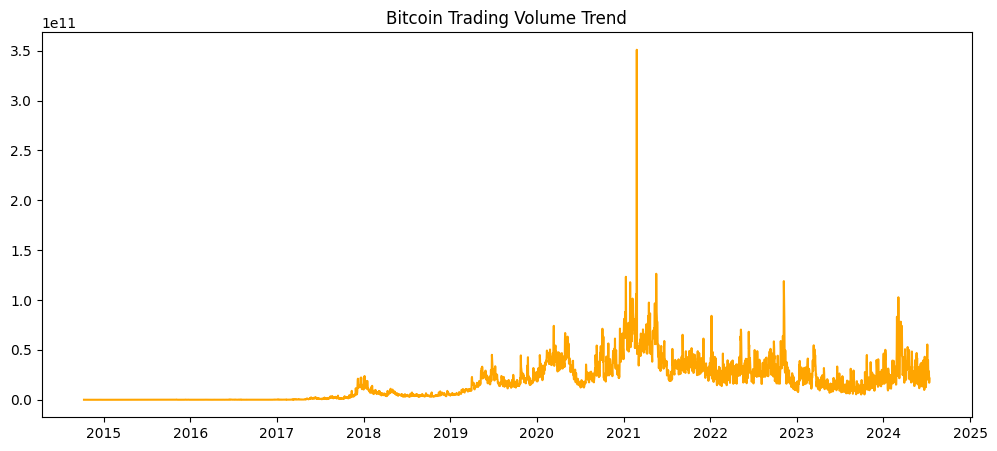

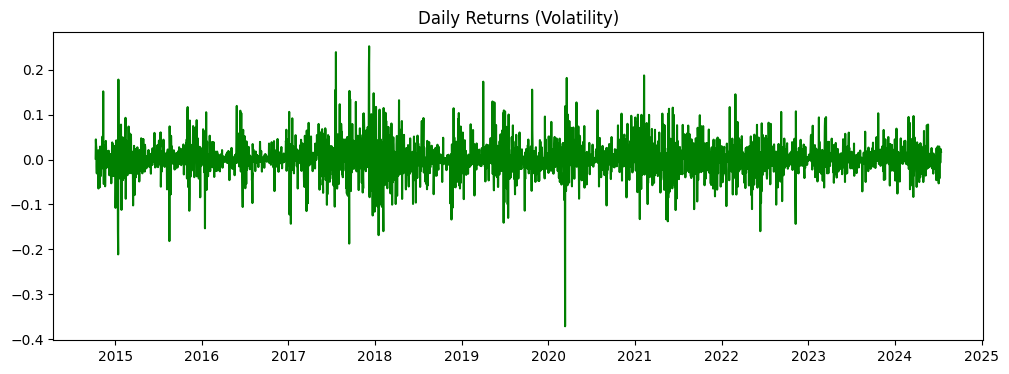

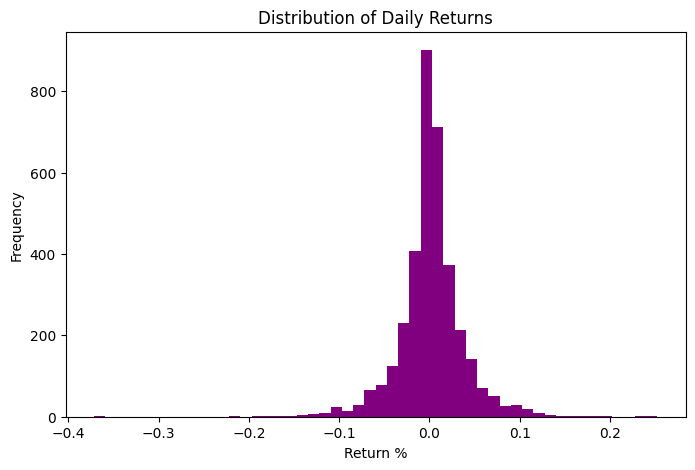

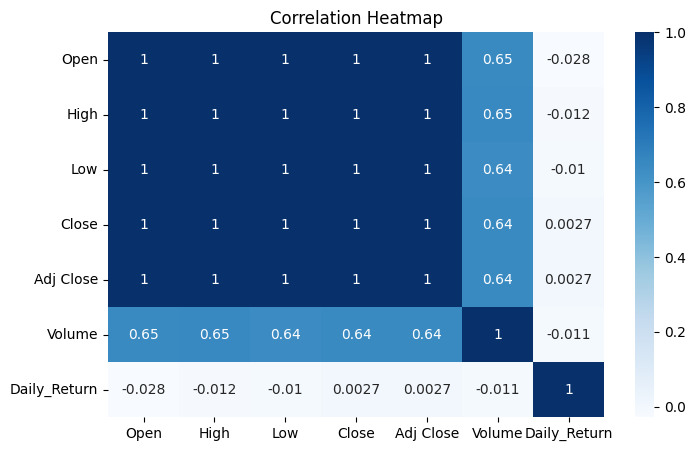

In [4]:
# EXPLORATORY DATA ANALYSIS (EDA)

# Close Price Trend
plt.figure(figsize=(12,5))
plt.plot(df["Close"])
plt.title("Bitcoin Close Price Trend")
plt.xlabel("Year")
plt.ylabel("Price")
plt.show()

# Volume Trend
plt.figure(figsize=(12,5))
plt.plot(df["Volume"], color="orange")
plt.title("Bitcoin Trading Volume Trend")
plt.show()

# Daily Returns
df["Daily_Return"] = df["Close"].pct_change()

plt.figure(figsize=(12,4))
plt.plot(df["Daily_Return"], color="green")
plt.title("Daily Returns (Volatility)")
plt.show()

# Return Distribution
plt.figure(figsize=(8,5))
plt.hist(df["Daily_Return"].dropna(), bins=50, color="purple")
plt.title("Distribution of Daily Returns")
plt.xlabel("Return %")
plt.ylabel("Frequency")
plt.show()

# Correlation Heatmap
plt.figure(figsize=(8,5))
sns.heatmap(df.corr(), annot=True, cmap="Blues")
plt.title("Correlation Heatmap")
plt.show()

In [5]:
# FEATURE ENGINEERING

data = df.copy()

data["Return_1d"] = data["Close"].pct_change()
data["MA7"] = data["Close"].rolling(7).mean()
data["MA21"] = data["Close"].rolling(21).mean()
data["Lag_1"] = data["Close"].shift(1)

data = data.dropna()

features = ["Return_1d", "MA7", "MA21", "Lag_1"]
print("\nFeatures Used:", features)


Features Used: ['Return_1d', 'MA7', 'MA21', 'Lag_1']


In [6]:
# TRAIN–TEST SPLIT

test_days = 90

train = data.iloc[:-test_days]
test = data.iloc[-test_days:]

X_train = train[features].values
y_train = train["Close"].values

X_test = test[features].values
y_test = test["Close"].values

print("\nTrain Size:", len(train))
print("Test Size:", len(test))


Train Size: 3456
Test Size: 90


In [7]:
# MODEL 1: GRADIENT BOOSTING (ML Model)

print("\nTraining Gradient Boosting Model...")

gb = GradientBoostingRegressor()
gb.fit(X_train, y_train)

pred_gb = gb.predict(X_test)
rmse_gb = np.sqrt(mean_squared_error(y_test, pred_gb))

print("Gradient Boosting RMSE:", rmse_gb)


Training Gradient Boosting Model...
Gradient Boosting RMSE: 571.6194320329931


In [8]:
# MODEL 2: ARIMA (Simple Time-Series)

print("\nTraining ARIMA Model...")

try:
    arima_model = ARIMA(train["Close"], order=(1,1,1)).fit()
    pred_arima = arima_model.forecast(len(test))
    rmse_arima = np.sqrt(mean_squared_error(y_test, pred_arima))
    print("ARIMA RMSE:", rmse_arima)
except:
    pred_arima = np.full(len(test), np.nan)
    rmse_arima = np.nan
    print("ARIMA Failed")


Training ARIMA Model...
ARIMA RMSE: 3948.214454999336


In [9]:
# MODEL 3: SARIMAX (Advanced)

print("\nTraining SARIMAX Model...")

try:
    sar_model = SARIMAX(
        train["Close"], order=(1,1,1),
        seasonal_order=(1,1,1,7)
    ).fit(disp=False)

    pred_sar = sar_model.forecast(len(test))
    rmse_sar = np.sqrt(mean_squared_error(y_test, pred_sar))
    print("SARIMAX RMSE:", rmse_sar)

except Exception as e:
    pred_sar = np.full(len(test), np.nan)
    rmse_sar = np.nan
    print("SARIMAX Failed:", e)


Training SARIMAX Model...
SARIMAX RMSE: 4048.8271623169753


In [10]:
# ACCURACY METRICS

def safe_metric(metric_fn, y_true, y_pred):
    try:
        return metric_fn(y_true, y_pred)
    except:
        return np.nan

# R2 Score
r2_gb = safe_metric(r2_score, y_test, pred_gb)
r2_arima = safe_metric(r2_score, y_test, pred_arima)
r2_sar = safe_metric(r2_score, y_test, pred_sar)

# MAPE
mape_gb = safe_metric(mean_absolute_percentage_error, y_test, pred_gb) * 100
mape_arima = safe_metric(mean_absolute_percentage_error, y_test, pred_arima) * 100
mape_sar = safe_metric(mean_absolute_percentage_error, y_test, pred_sar) * 100

# Accuracy %
acc_gb = 100 - mape_gb
acc_arima = 100 - mape_arima
acc_sar = 100 - mape_sar

# Summary Table
accuracy_table = pd.DataFrame({
    "Model": ["Gradient Boosting", "ARIMA", "SARIMAX"],
    "RMSE": [rmse_gb, rmse_arima, rmse_sar],
    "R2 Score": [r2_gb, r2_arima, r2_sar],
    "MAPE (%)": [mape_gb, mape_arima, mape_sar],
    "Accuracy (%)": [acc_gb, acc_arima, acc_sar]
})

print("\nMODEL PERFORMANCE SUMMARY")
print(accuracy_table)


MODEL PERFORMANCE SUMMARY
               Model         RMSE  R2 Score  MAPE (%)  Accuracy (%)
0  Gradient Boosting   571.619432  0.978389  0.697057     99.302943
1              ARIMA  3948.214455 -0.031020  5.099768     94.900232
2            SARIMAX  4048.827162 -0.084237  5.234989     94.765011


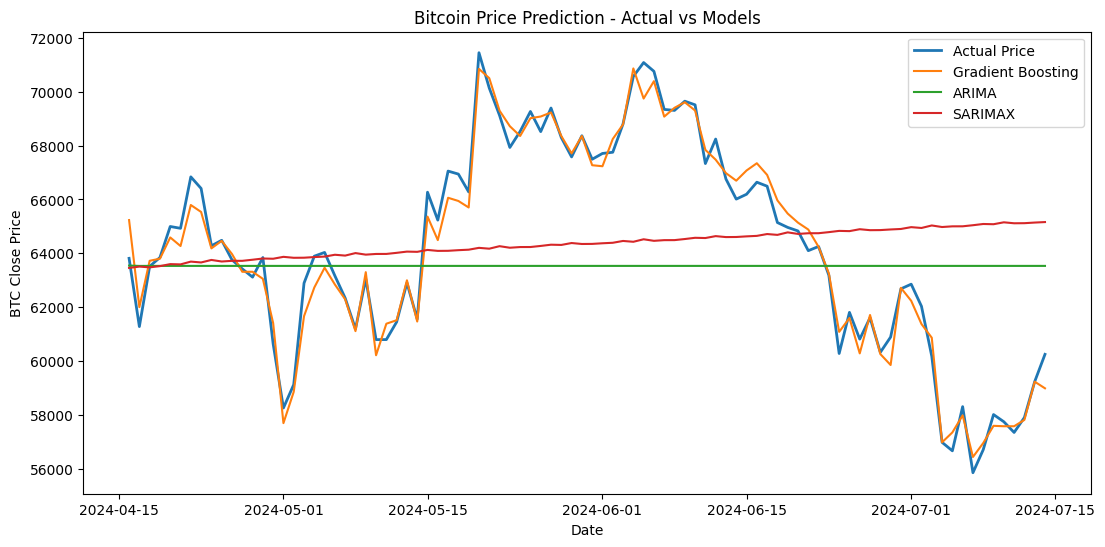


🎉 PROJECT COMPLETED SUCCESSFULLY!


In [11]:
# PREDICTION PLOT

plt.figure(figsize=(13,6))
plt.plot(test.index, y_test, label="Actual Price", linewidth=2)
plt.plot(test.index, pred_gb, label="Gradient Boosting")
plt.plot(test.index, pred_arima, label="ARIMA")
plt.plot(test.index, pred_sar, label="SARIMAX")

plt.title("Bitcoin Price Prediction - Actual vs Models")
plt.xlabel("Date")
plt.ylabel("BTC Close Price")
plt.legend()
plt.show()

print("\n🎉 PROJECT COMPLETED SUCCESSFULLY!")